# Data Cleaning

In [2]:
import sys
import os
import logging
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Add project root to path for imports
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Load environment and config (force refresh)
load_dotenv(project_root / '.env', override=True)
from soeSpotify import config

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
palette = sns.color_palette("viridis", as_cmap=False)

print("Setup complete.")

Setup complete.


In [3]:
print("Loading analytical datasets...")

# We use the analytics stage data as it is already cleaned and joined
df_tracks = pd.read_parquet(config.ANALYTICS_TRACKS)
df_artists = pd.read_parquet(config.ANALYTICS_ARTISTS)
df_genres = pd.read_parquet(config.ANALYTICS_GENRES)
df_features = pd.read_parquet(config.ANALYTICS_TRACK_FEATURES)

print(f"Tracks loaded:   {len(df_tracks):,}")
print(f"Artists loaded:  {len(df_artists):,}")
print(f"Genres loaded:   {len(df_genres):,}")
print(f"Features loaded: {len(df_features):,}")

Loading analytical datasets...
Tracks loaded:   101,144
Artists loaded:  56,129
Genres loaded:   87,202
Features loaded: 101,144


## Preprocessing Genres

The genres column contains a list of genres for most artists. The genres defined are extremely granular such as 	danish pop rock or quebecois hip hop. in the first step we split up the list and only retain a primary and a secondary genre. There are over 2000 unique genres.

In [4]:
import ast

def _parse_genres(val):
    if pd.isna(val):
        return {"primary_genre": "", "secondary_genre": ""}

    # Already a list-like object
    if isinstance(val, (list, tuple)):
        primary = val[0] if len(val) >= 1 else ""
        secondary = val[1] if len(val) >= 2 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    # String representation (e.g. "['rock', 'indie']" or "[]")
    if isinstance(val, str):
        s = val.strip()
        if s in ("", "[]"):
            return {"primary_genre": "", "secondary_genre": ""}
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple)):
                primary = parsed[0] if parsed else ""
                secondary = parsed[1] if len(parsed) > 1 else ""
                return {"primary_genre": primary, "secondary_genre": secondary}
        except Exception:
            pass
        # Fallback: split on commas inside the brackets
        s2 = s.strip("[]")
        parts = [p.strip().strip("\"\'") for p in s2.split(",") if p.strip()]
        primary = parts[0] if parts else ""
        secondary = parts[1] if len(parts) > 1 else ""
        return {"primary_genre": primary, "secondary_genre": secondary}

    return {"primary_genre": "", "secondary_genre": ""}

# Apply parser and append columns to df_artists
_parsed = df_artists["genres"].apply(_parse_genres).apply(pd.Series)
df_artists = pd.concat([df_artists, _parsed], axis=1)

# Show the new columns
df_artists[["genres", "primary_genre", "secondary_genre"]].head()

,genres,primary_genre,secondary_genre
0,"['sertanejo', 'sertanejo pop', 'sertanejo trad...",sertanejo,sertanejo pop
1,[],,
2,['danish pop rock'],danish pop rock,
3,['uk alternative pop'],uk alternative pop,
4,['french baroque'],french baroque,


In [5]:
df_artists["primary_genre"].unique()

<ArrowStringArray>
[          'sertanejo',                    '',     'danish pop rock',
  'uk alternative pop',      'french baroque', 'classic finnish pop',
              'pagode',    'abstract hip hop',     'classical cello',
               'brega',
 ...
             'klezmer',        'chill groove',  'finnish rockabilly',
          'kinderchor',         'turin indie',   'southampton indie',
           'slow core',          'fijian pop',       'swiss hip hop',
            'nu metal']
Length: 2154, dtype: str

In [6]:
primary_genre_counts = df_artists["primary_genre"].value_counts()
rare_primary_genres = primary_genre_counts[primary_genre_counts < 2]
print(len(rare_primary_genres))

413


There are over 2000 unique genres. However over 400 of these genres only occur for one artist. These are meaningless as categorical variables as they make their own unique categories.

As a secondary catch we will map the genres to broader, bigger categories as a second tier category, that can be used as a fall-back option in recommenders, when the more specific genre is exhausted. As a result of this for example "swiss hip hop" and "abstract hip hop" will be in teh same broad category of "hip hop".

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

/Users/radakovic/Desktop/FH_DS/SS26/solution_eng/soe-spotify/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
model = SentenceTransformer('all-MiniLM-L6-v2')

broad_genres = ['pop', 'rock', 'hip hop', 'indie', 'electronic', 
                'folk', 'r&b', 'jazz', 'classical', 'metal', 'house', 'blues', 'world']

broad_embeddings = model.encode(broad_genres)

def assign_broad_genre(genre):
    genre_emb = model.encode([genre])
    sims = cosine_similarity(genre_emb, broad_embeddings)[0]
    return broad_genres[np.argmax(sims)]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8431.67it/s]


In [9]:
all_genres = pd.concat([df_artists['primary_genre'], df_artists['secondary_genre']]).unique()
print(f"Total unique genres: {len(all_genres)}")

Total unique genres: 2347


In [10]:
genre_to_broad = {genre: assign_broad_genre(genre) for genre in all_genres if genre}
df_artists['primary_genre_broad'] = df_artists['primary_genre'].map(genre_to_broad).fillna(df_artists['primary_genre'])
df_artists['secondary_genre_broad'] = df_artists['secondary_genre'].map(genre_to_broad).fillna(df_artists['secondary_genre'])   

In [11]:
mask = (
    df_artists[['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']]
    .apply(lambda col: col.notna() & (col.str.strip() != ''))
    .all(axis=1)
)

df_artists[mask][['primary_genre', 'secondary_genre', 'primary_genre_broad', 'secondary_genre_broad']].head(10)

,primary_genre,secondary_genre,primary_genre_broad,secondary_genre_broad
0,sertanejo,sertanejo pop,world,pop
11,pagode,sertanejo,rock,world
18,sertanejo,sertanejo tradicional,world,classical
22,sertanejo,sertanejo tradicional,world,classical
23,brega,sertanejo tradicional,r&b,classical
26,abstract hip hop,experimental hip hop,hip hop,hip hop
33,diva house,hip house,house,house
43,deep chiptune,filter house,rock,house
44,blues,blues-rock,blues,blues
49,pagode,sertanejo,rock,world


## Podcast filtering

The data contains not only music but interviews, podcasts, comedy and talk shows as well. These need to be filtered out, however there is no one clear indicator of these.
After exploration in the databse and domain knowledge here are some meaningful guidelines:
- speechiness is above 0.6
- duration is typically longer for podcasts compared to music
- intrumentalness is below 0.1 
But to all these rules exceptions apply.

In [12]:
df_tracks['duration_minutes'] = df_tracks['duration_ms'] / 60000

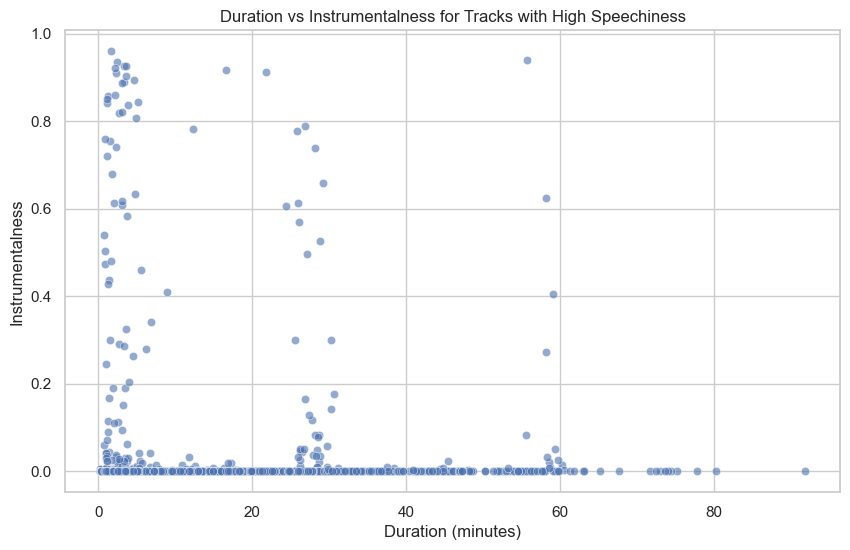

In [13]:
df_filtered = df_tracks[df_tracks['speechiness'] > 0.6]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()

We see that for the subset with speechiness above 0.6 the majority of the tracks have low instrumentalness and rather longer duration. This is a clear sign for podcasts. Even shorter tracks with low instrumentalness are presumably not music due to the combination of high speechiness and low instruemntalness.

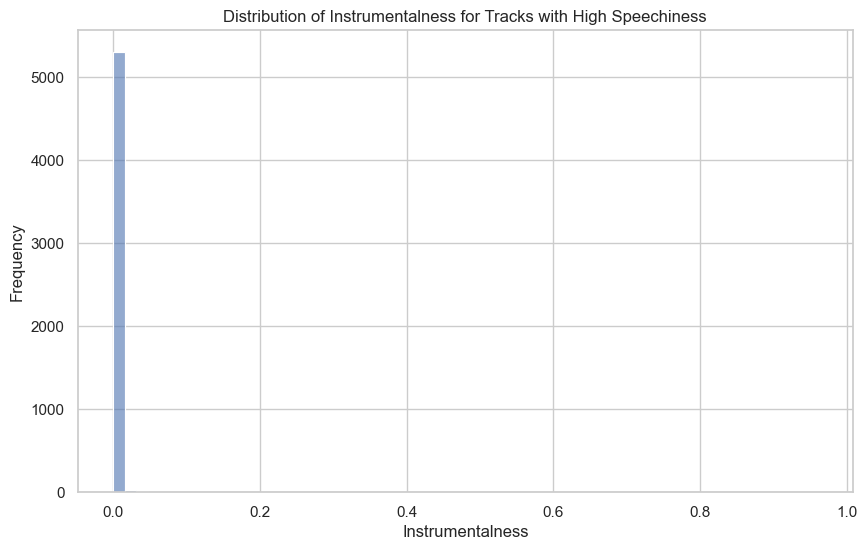

In [14]:
#create a histogram of instrumentalness for tracks that have speechiness above 0.6
df_filtered = df_tracks[df_tracks['speechiness'] > 0.6]
plt.figure(figsize=(10, 6))
sns.histplot(data=df_filtered, x='instrumentalness', bins=60, alpha=0.6)
plt.title('Distribution of Instrumentalness for Tracks with High Speechiness')
plt.xlabel('Instrumentalness')
plt.ylabel('Frequency')
plt.show()

In [15]:
num_tracks = len(df_filtered)
num_instrumental = (df_filtered['instrumentalness'] > 0.1).sum()
percentage_instrumental = (num_instrumental / num_tracks) * 100
print(f"Total tracks with speechiness > 0.6: {num_tracks}")
print(f"Tracks with instrumentalness > 0.1: {num_instrumental}")
print(f"Percentage instrumental: {percentage_instrumental:.2f}%")

Total tracks with speechiness > 0.6: 5431
Tracks with instrumentalness > 0.1: 76
Percentage instrumental: 1.40%


Verdict is to exclude all tracks with speechiness above 0.6. We risk the exclusion of 76 potential music tracks. However the cost of leaving a podcast in is greater, than the loss of excluding music so we decided to set the cutoff thresholds accordingly.

We move on to lower speechiness tracks. namely the next bin is speechiness between 0.5 and 0.6.

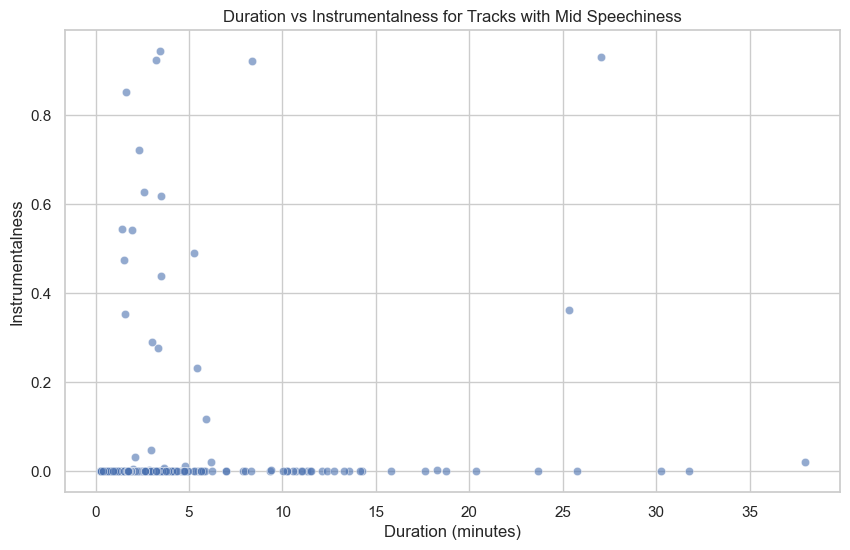

In [17]:
df_filtered = df_tracks[(df_tracks['speechiness'] <= 0.6) & (df_tracks['speechiness'] > 0.55)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Mid Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()

Here due to the lower threshold of speechiness we will also require low instrumentalness (under 0.1) for cutoff.

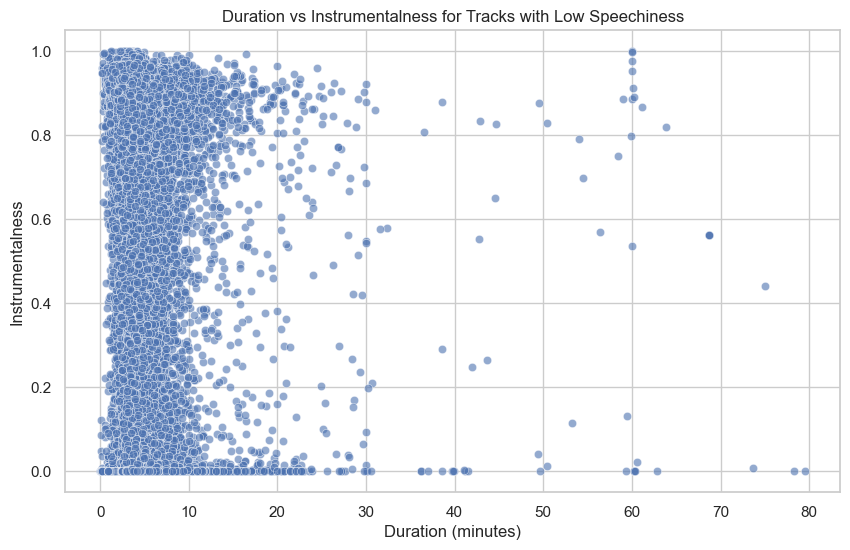

In [18]:
 
df_filtered = df_tracks[(df_tracks['speechiness'] <= 0.5)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='duration_minutes', y='instrumentalness', alpha=0.6)
plt.title('Duration vs Instrumentalness for Tracks with Low Speechiness')
plt.xlabel('Duration (minutes)')
plt.ylabel('Instrumentalness')
plt.show()

For speechiness under 0.5, we clearly see the instrumentalness shoots up substantially compared to the previous two graphs.

### Conclusion
From the perspective of the project the exclusion of a few music tracks is less of an issue, compared to leaving in some non-music tracks. With that being said we will apply the following exclusion logic for non-music tracks.
Exclude all tracks with:
- speechiness above 0.6
- duration above 10 minutes (also full concert recordings and such)
- speechiness between 0.5 and 0.6 and instrumentalness under 0.1

Disclaimer: values of 0 in instrumentalness likely denote missing values rather than no instrumentalness.


In [19]:
df_tracks.shape

(101144, 34)

In [20]:
# drop tracks with speechniness above 0.6, or duration above 10 mins, or speechiness between 0.5 and 0.6 and instrumentalness under 0.1
df_cleaned = df_tracks[
    (df_tracks['speechiness'] <= 0.6) &
    (df_tracks['duration_minutes'] <= 10) &
    ~((df_tracks['speechiness'] > 0.5) & (df_tracks['speechiness'] <= 0.6) & (df_tracks['instrumentalness'] < 0.1))
]
df_cleaned.shape

(94065, 34)

This filtering heuristic eliminated around 7000 observations.